# Fetch parcellations and matrix indexing


## Matrix Indexing and Coverage

`micapipe v0.2.3` generates several connectivity matrices, all saved as `GIFTI` files.  
The size of each matrix depends on the method used to generate it and on the matrix type.

### GD and MPC

- Indices correspond **only to cortical regions**.
- The **midwall** is always assigned index ``0``.
- These matrices **exclude subcortical and cerebellar connections**; only cortical nodes are represented.
- These matrices reflect **cortical connectivity**, suitable for GD/MPC analyses.

### SC: Structural Connectomes

- Indices **0–47** correspond to **subcortical and cerebellar nodes**.
- These indices match the labels in the lookup table: ``lut_subcortical-cerebellum_mics.csv``.
- Cortical regions follow after the first 48 indices.
- Structural connectomes include **both cortical and subcortical/cerebellar nodes**.

### FC: Functional Connectomes

- Functional connectomes usually have **one ROI fewer than structural connectomes**.
- The left and right midwall regions are merged into a single label during FC calculation.
- Only cortical and subcortical/cerebellar ROIs are included according to the parcellation scheme used.


<div align="center">
  Connectome dimensions
</div>


| **parc**        | **GD shape** | **MPC shape** | **SC shape** | **FC shape** | **SC sub/cerb** | **FC sub/cer** |
|-----------------|--------------|---------------|--------------|--------------|---------------|---------------|
| `fsLR-5k`       | 9684 x 9684  | 9684 x 9684   | 9684 x 9684  | 9684 x 9684  | 0             | 0             |
| `aparc-a2009s`  | 150 x 150    | 150 x 150     | 198 x 198    | 199 x 199    | 48            | 49            |
| `aparc`         | 72 x 72      | 72 x 72       | 120 x 120    | 119 x 119    | 48            | 47            |
| `economo`       | 88 x 88      | 88 x 88       | 136 x 136    | 135 x 135    | 48            | 47            |
| `glasser-360`   | 362 x 362    | 362 x 362     | 410 x 410    | 409 x 409    | 48            | 47            |
| `schaefer-100`  | 102 x 102    | 102 x 102     | 150 x 150    | 149 x 149    | 48            | 47            |
| `schaefer-200`  | 202 x 202    | 202 x 202     | 250 x 250    | 249 x 249    | 48            | 47            |
| `schaefer-300`  | 302 x 302    | 302 x 302     | 350 x 350    | 349 x 349    | 48            | 47            |
| `schaefer-400`  | 402 x 402    | 402 x 402     | 450 x 450    | 449 x 449    | 48            | 47            |
| `schaefer-500`  | 502 x 502    | 502 x 502     | 550 x 550    | 549 x 549    | 48            | 47            |
| `schaefer-600`  | 602 x 602    | 602 x 602     | 650 x 650    | 649 x 649    | 48            | 47            |
| `schaefer-700`  | 702 x 702    | 702 x 702     | 750 x 750    | 749 x 749    | 48            | 47            |
| `schaefer-800`  | 802 x 802    | 802 x 802     | 850 x 850    | 849 x 849    | 48            | 47            |
| `schaefer-900`  | 902 x 902    | 902 x 902     | 950 x 950    | 949 x 949    | 48            | 47            |
| `schaefer-1000` | 1002 x 1002  | 1002 x 1002   | 1050 x 1050  | 1048 x 1048  | 48            | 46            |
| `vosdewael-100` | 102 x 102    | 102 x 102     | 150 x 150    | 149 x 149    | 48            | 47            |
| `vosdewael-200` | 202 x 202    | 202 x 202     | 250 x 250    | 249 x 249    | 48            | 47            |
| `vosdewael-300` | 302 x 302    | 302 x 302     | 350 x 350    | 349 x 349    | 48            | 47            |
| `vosdewael-400` | 402 x 402    | 402 x 402     | 450 x 450    | 449 x 449    | 48            | 47            |


## Warning
⚠️ **Known Issues / Indexing Errors**
      
- GD, SC, and MPC ``fsLR-32k``:

    -  **schaefer-700** → Indexing errors in both hemispheres.
    -  **schaefer-900** → Indexing errors in both hemispheres.
    -  **schaefer-1000** → Indexing errors in the **right hemisphere only**.
    -  **aparc-a2009s** → ``ValueError: There are more target labels than source values``.

- FC ``fsaverage5``:

    -  **schaefer-1000** → ``ValueError: There are more target labels than source values``.
    -  **aparc-a2009s** → Indexing inconsistencies (“weird indexing”).


# Subcortical and Cerebellar Lookup Table

The lookup table for the subcortical and cerebellar labels used in connectome construction is stored in the file:

``lut_subcortical-cerebellum_mics.csv``

relative to the [micapipe/parcellations/lut/](<https://github.com/MICA-MNI/micapipe/blob/master/parcellations/lut/lut_subcortical-cerebellum_mics.csv>) repository.


In [1]:
import pandas as pd

# micapipe URL
micapipe = 'https://raw.githubusercontent.com/MICA-MNI/micapipe/refs/heads/master'

# Load the subcortical/cerebellar lookup table as a pandas DataFrame
parc_subcer = pd.read_csv(
    f'{micapipe}/parcellations/lut/lut_subcortical-cerebellum_mics.csv'
)

# Display the lookup table
parc_subcer


,roi,mics,label,R,G,B,A,side,coor.x,coor.y,coor.z
0,1,10,Left-Thalamus-Proper,0,118,14,0.0,left,10.521300,-8.29844,-1.43616
1,2,11,Left-Caudate,122,186,220,0.0,left,14.155700,-35.71630,7.81321
2,3,12,Left-Putamen,236,13,176,0.0,left,25.818300,-29.41500,-2.07575
3,4,13,Left-Pallidum,12,48,255,0.0,left,19.432300,-23.83730,-4.78631
4,5,17,Left-Hippocampus,220,216,20,0.0,left,24.811600,-7.56246,-20.43630
5,6,18,Left-Amygdala,103,255,255,0.0,left,22.806200,-26.61340,-21.42560
6,7,26,Left-Accumbens-area,255,165,0,0.0,left,10.413900,-42.28550,-7.06962
7,8,49,Right-Thalamus-Proper,0,118,14,0.0,right,-13.769100,-9.22256,-1.59194
8,9,50,Right-Caudate,122,186,220,0.0,right,-15.990000,-36.57850,7.61626
9,10,51,Right-Putamen,236,13,176,0.0,right,-27.151900,-31.08790,-2.92287


# Cortical labels

In [2]:
# Set the environment
import os
import glob
import numpy as np
import nibabel as nib
from brainspace.plotting import plot_hemispheres
from brainspace.mesh.mesh_io import read_surface
from brainspace.datasets import load_conte69
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt
import cmocean

# Add cmocean maps to cmaps variable
cmaps = cmocean.cm.cmap_d

# Set the working directory to the 'out' directory
out='/data_/mica3/BIDS_PNI/derivatives'
os.chdir(out)     # <<<<<<<<<<<< CHANGE THIS PATH

# This variable will be different for each subject
sub='PNC019' # <<<<<<<<<<<< CHANGE THIS SUBJECT's ID
ses='a1'    # <<<<<<<<<<<< CHANGE THIS SUBJECT's SESSION
subjectID=f'sub-{sub}_ses-{ses}'           
subjectDir=f'micapipe_v0.2.0/sub-{sub}/ses-{ses}' 

# Path to MICAPIPE from global enviroment
micapipe=os.popen("echo $MICAPIPE").read()[:-1] # <<<<<<<<<<<< CHANGE THIS PATH

# All parcelations list
parc = ['aparc-a2009s', 'aparc', 'economo', 'glasser-360',
         'schaefer-100','schaefer-200','schaefer-300','schaefer-400',
         'schaefer-500','schaefer-600','schaefer-700','schaefer-800',
         'schaefer-900','schaefer-1000','vosdewael-100','vosdewael-200',
         'vosdewael-300','vosdewael-400']


### Load the standard inflated surfaces

In [3]:
# Load fsLR-5k inflated (9684 vertices both hemispheres)
f5k_lh = read_surface(f'{micapipe}/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
f5k_rh = read_surface(f'{micapipe}/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

# Load fsLR-32k inflated (64984 vertices both hemispheres)
f32k_lh = read_surface(f'{micapipe}/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_rh = read_surface(f'{micapipe}/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')

# Load fsaverage5 inflated (20484 vertices both hemispheres)
fs5_lh = read_surface(f'{micapipe}/surfaces/fsaverage5/surf/lh.inflated', itype='fs')
fs5_rh = read_surface(f'{micapipe}/surfaces/fsaverage5/surf/rh.inflated', itype='fs')


### Create a function that loads the parcellations

In [4]:
def load_annot(atlas, surf='fsaverage5'):
    '''
    Script that loads the labels of an specific parcellation and generates a midwall mask
    '''
    
    # Load LEFT annotation file in fsaverage5
    annot_lh_fs5= nib.freesurfer.read_annot(f'{micapipe}/parcellations/lh.{atlas}_mics.annot')

    # Unique number of labels of a given atlas
    Ndim = max(np.unique(annot_lh_fs5[0]))
    
    if surf == 'fsaverage5':

        # Load RIGHT annotation file in fsaverage5
        annot_rh_fs5= nib.freesurfer.read_annot(f'{micapipe}/parcellations/rh.{atlas}_mics.annot')[0]+Ndim

        # replace with 0 the medial wall of the right labels
        annot_rh_fs5 = np.where(annot_rh_fs5==Ndim, 0, annot_rh_fs5) 

        # fsaverage5 labels
        labels = np.concatenate((annot_lh_fs5[0], annot_rh_fs5), axis=0)
    
    else:
        # Read label for fsLR-32k
        labels = np.loadtxt(open(f'{micapipe}/parcellations/{atlas}_conte69.csv'), dtype=int)

    # mask of the medial wall
    mask = labels != 0
    
    # Midwall labels of aparc-a2009s are lh=42 and rh=117
    if atlas == 'aparc-a2009s' and surf == 'fsaverage5':
        mask[(labels == 117) | (labels == 42)] = 0
    
    return(labels, mask, Ndim)


In [5]:
# Empty list of surface plots
surf_fs5 = [None] * len(parc)
surf_32k = [None] * len(parc)

# NaN color
nan_col = (0.8, 0.8, 0.8, 1)

# Iterate over each parcellation to create a list of surface plots
for i, g in enumerate(parc):
    
    # Load fsaverage5 labels
    labels_fs5, mask_fs5, _ = load_annot(g, surf='fsaverage5')
    # Load fsLR-32k labels
    labels_32k, mask_32k, _ = load_annot(g, surf='fsLR-32k')

    # Map labels to surface fsaverage5
    surf_fs5[i] = map_to_labels(np.unique(labels_fs5.astype(float)), labels_fs5,  fill=np.nan, mask=mask_fs5)
    # Map labels to surface fsLR-32k
    surf_32k[i] = map_to_labels(np.unique(labels_fs5.astype(float)), labels_32k,  fill=np.nan, mask=mask_32k)


## Anatomy based parcellations 

### Desikan-Killiany (aka Freesurfer aparc)
> Desikan, R. S., Ségonne, F., Fischl, B., Quinn, B. T., Dickerson, B. C., Blacker, D., ... & Albert, M. S. (2006). An automated labeling system for subdividing the human cerebral cortex on MRI scans into gyral based regions of interest. Neuroimage, 31(3), 968-980.

### Dextrieux (aka Freesurfer aparc-a2009s)
> Destrieux, C., Fischl, B., Dale, A., & Halgren, E. (2010). Automatic parcellation of human cortical gyri and sulci using standard anatomical nomenclature. Neuroimage, 53(1), 1-15.


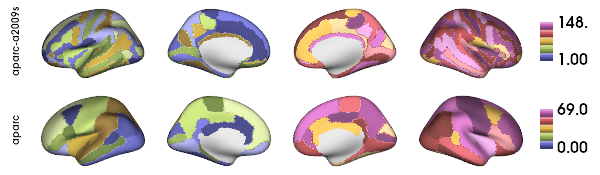

In [6]:
# fsaverage5 | Plot parcellations
plot_hemispheres(fs5_lh, fs5_rh, array_name=surf_fs5[0:2], size=(600, 175), cmap='tab20b',
                 embed_nb=True, label_text={'left':parc[0:2]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

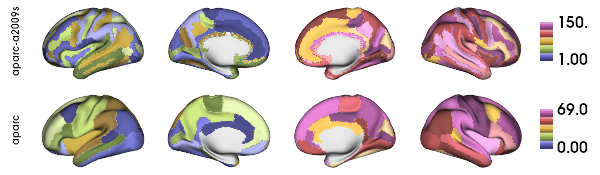

In [7]:
# fsLR-32k | Plot parcellations
plot_hemispheres(f32k_lh, f32k_rh, array_name=surf_32k[0:2], size=(600, 175), cmap='tab20b',
                 embed_nb=True, label_text={'left':parc[0:2]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

## Histology based parcellation


### Economo-Koskinas
> Scholtens, L. H., de Reus, M. A., de Lange, S. C., Schmidt, R., & van den Heuvel, M. P. (2018). An mri von economo–koskinas atlas. NeuroImage, 170, 249-256.


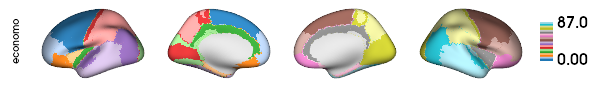

In [8]:
# Plot parcellations fsaverage5
plot_hemispheres(fs5_lh, fs5_rh, array_name=surf_fs5[2], size=(600, 87), cmap='tab20',
                 embed_nb=True, label_text={'left':[parc[2]]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

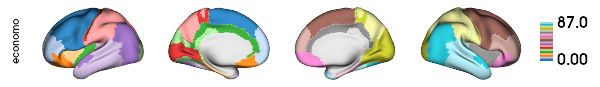

In [9]:
# Plot parcellations fsLR32k
plot_hemispheres(f32k_lh, f32k_rh, array_name=surf_32k[2], size=(600, 87), cmap='tab20',
                 embed_nb=True, label_text={'left':[parc[2]]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

## Multimodal based parcellation

### Glasser
> Glasser, M. F., Coalson, T. S., Robinson, E. C., Hacker, C. D., Harwell, J., Yacoub, E., ... & Smith, S. M. (2016). A multi-modal parcellation of human cerebral cortex. Nature, 536(7615), 171-178.


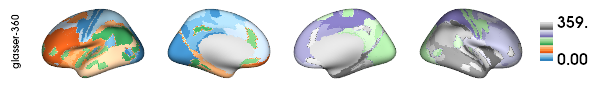

In [10]:
# Plot parcellations
plot_hemispheres(fs5_lh, fs5_rh, array_name=surf_fs5[3], size=(600, 87), cmap='tab20c',
                 embed_nb=True, label_text={'left':[parc[3]]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

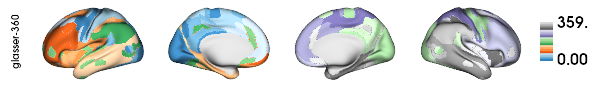

In [11]:
# Plot parcellations
plot_hemispheres(f32k_lh, f32k_rh, array_name=surf_32k[3], size=(600, 87), cmap='tab20c',
                 embed_nb=True, label_text={'left':[parc[3]]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

## Functional based parcellation

### Schaefer 100-1000
> Schaefer, A., Kong, R., Gordon, E. M., Laumann, T. O., Zuo, X. N., Holmes, A. J., ... & Yeo, B. T. (2018). Local-global parcellation of the human cerebral cortex from intrinsic functional connectivity MRI. Cerebral cortex, 28(9), 3095-3114.


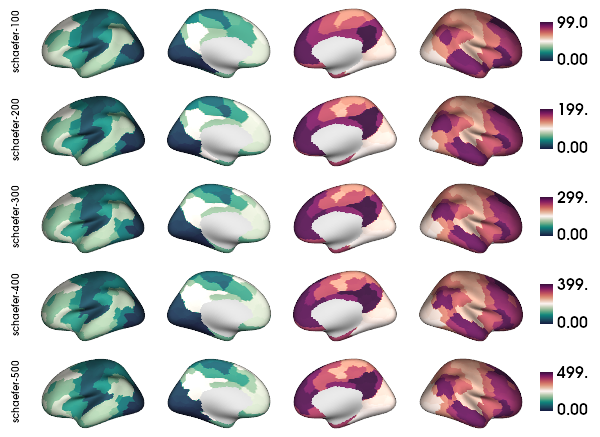

In [12]:
# Plot parcellations
plot_hemispheres(fs5_lh, fs5_rh, array_name=surf_fs5[4:9], size=(600, 437), cmap='cmo.curl',
                 embed_nb=True, label_text={'left':parc[4:9]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

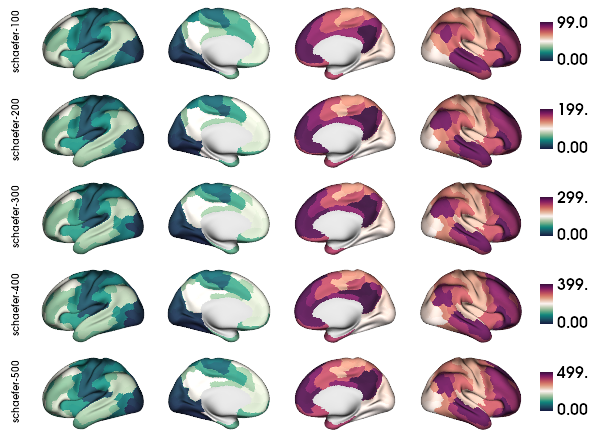

In [13]:
# Plot parcellations
plot_hemispheres(f32k_lh, f32k_rh, array_name=surf_32k[4:9], size=(600, 437), cmap='cmo.curl',
                 embed_nb=True, label_text={'left':parc[4:9]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

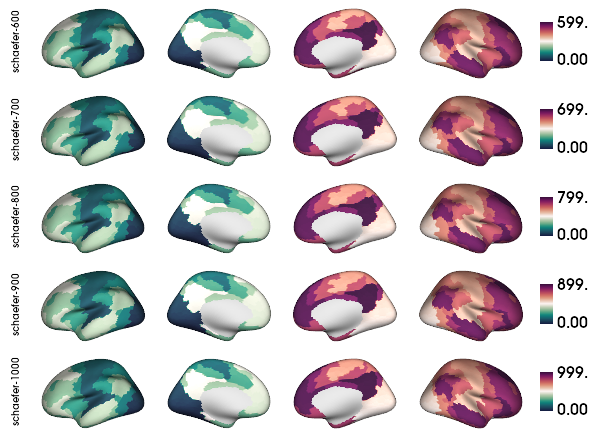

In [14]:
# Plot parcellations
plot_hemispheres(fs5_lh, fs5_rh, array_name=surf_fs5[9:14], size=(600, 437), cmap='cmo.curl',
                 embed_nb=True, label_text={'left':parc[9:14]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

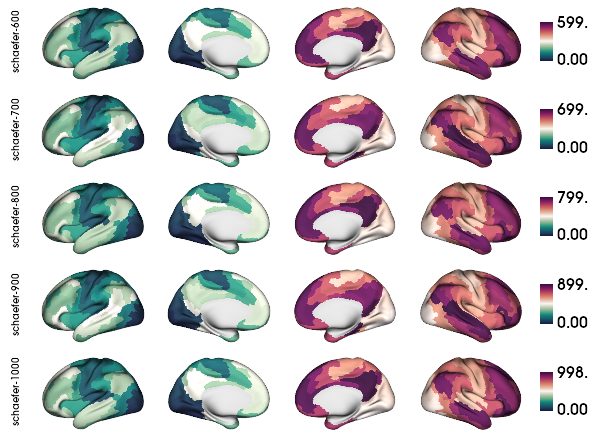

In [15]:
# Plot parcellations
plot_hemispheres(f32k_lh, f32k_rh, array_name=surf_32k[9:14], size=(600, 437), cmap='cmo.curl',
                 embed_nb=True, label_text={'left':parc[9:14]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

## Pseudo-random parcellation based on `Desikan Killiany`

### DK-random 100-500
vosdewael parcellations are semi-random subparcellations of Desikan Killiany, obtained by spliting in two the bigest parcel iterativelly until the desired number of parcels is reached.


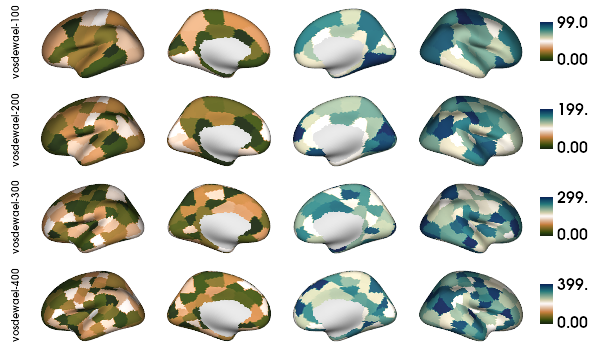

In [16]:
# Plot parcellations
plot_hemispheres(fs5_lh, fs5_rh, array_name=surf_fs5[14:18], size=(600, 350), cmap='cmo.tarn',
                 embed_nb=True, label_text={'left':parc[14:18]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

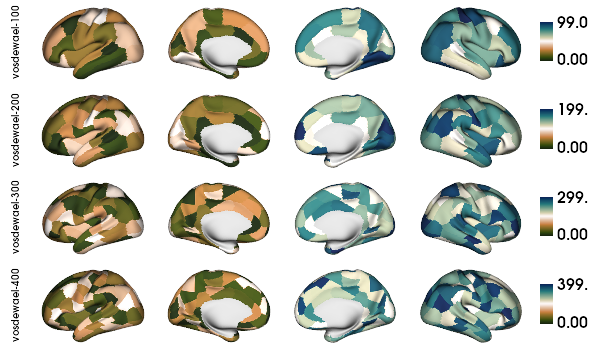

In [17]:
# Plot parcellations
plot_hemispheres(f32k_lh, f32k_rh, array_name=surf_32k[14:18], size=(600, 350), cmap='cmo.tarn',
                 embed_nb=True, label_text={'left':parc[14:18]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

# Define functions to load each connectome

In [18]:
def load_mpc(File, Ndim):
    """Loads and process a MPC"""

    # load the matrix
    mtx_mpc = nib.load(File).darrays[0].data

    # Mirror the matrix
    MPC = np.triu(mtx_mpc,1)+mtx_mpc.T

    # Remove the medial wall
    MPC = np.delete(np.delete(MPC, 0, axis=0), 0, axis=1)
    MPC = np.delete(np.delete(MPC, Ndim, axis=0), Ndim, axis=1)
    
    return(MPC)

def load_fc(File, Ndim, parc=''):
    """Loads and process a functional connectome"""

    # load the matrix
    mtx_fs = nib.load(File).darrays[0].data

    # slice the matrix remove subcortical nodes and cerebellum
    FC = mtx_fs[49:, 49:]
    
    # Fisher transform
    FCz = np.arctanh(FC)

    # replace inf with 0
    FCz[~np.isfinite(FCz)] = 0

    # Mirror the matrix
    FCz = np.triu(FCz,1)+FCz.T
    return(FCz)

def load_gd(File, Ndim):
    """Loads and process a GD"""

    # load the matrix
    mtx_gd = nib.load(File).darrays[0].data

    # Remove the Mediall Wall
    mtx_gd = np.delete(np.delete(mtx_gd, 0, axis=0), 0, axis=1)
    GD = np.delete(np.delete(mtx_gd, Ndim, axis=0), Ndim, axis=1)

    return(GD)

def load_sc(File, Ndim, log_transform=True):
    """Loads and process a structura connectome"""

    # load the matrix
    mtx_sc = nib.load(File).darrays[0].data

    # Mirror the matrix
    if log_transform != True:
        mtx_sc = np.triu(mtx_sc,1)+mtx_sc.T
    else:
        mtx_sc = np.log(np.triu(mtx_sc,1)+mtx_sc.T)
    mtx_sc[np.isneginf(mtx_sc)] = 0

    # slice the matrix remove subcortical nodes and cerebellum
    SC = mtx_sc[49:, 49:]
    SC = np.delete(np.delete(SC, Ndim, axis=0), Ndim, axis=1)

    # replace 0 values with almost 0
    SC[SC==0] = np.finfo(float).eps
    
    return(SC)

# Load connectomes function

Now, let's create a function to load the connectomes and get the column mean of each modality including the `FC`.

In [19]:
def load_connectomes(connectome_type, parc, subjectDir, subjectID):
    """
    Load the specified connectome type and return roi_32k and roi_fs5.

    Parameters:
    connectome_type (str): Type of connectome to load. Options are 'GD', 'SC', 'MPC', 'FC'.
    subjectDir (str): Directory containing the subject data.
    subjectID (str): Subject ID.

    Returns:
    tuple: roi_32k and roi_fs5 arrays if successful, None otherwise.
    """
    
    # Empty list of surface plots
    roi_fs5 = [None] * len(parc)
    roi_32k = [None] * len(parc)

    for i, atlas in enumerate(parc):

        # Load fsaverage5 labels
        labels_fs5, mask_fs5, Ndim = load_annot(atlas, surf='fsaverage5')

        # Load fsLR-32k labels
        labels_32k, mask_32k, _ = load_annot(atlas, surf='fsLR-32k')

        try:
            if connectome_type == 'GD':
                # Load Geodesic Distance connectome
                file = f'{subjectDir}/dist/{subjectID}_atlas-{atlas}_GD.shape.gii'
                mtx = load_gd(file, Ndim)
            elif connectome_type == 'SC':
                # Load Structural Connectome
                file = f'{subjectDir}/dwi/connectomes/{subjectID}_space-dwi_atlas-{atlas}_desc-iFOD2-40M-SIFT2_full-connectome.shape.gii'
                mtx = load_sc(file, Ndim)
            elif connectome_type == 'MPC':
                # Load MPC
                acq_mpc = 'T1map'
                file = f'{subjectDir}/mpc/acq-{acq_mpc}/{subjectID}_atlas-{atlas}_desc-MPC.shape.gii'
                mtx = load_mpc(file, Ndim)
            elif connectome_type == 'FC':
                # Load Functional Connectome
                acq_func = 'desc-me_task-rest_bold'
                file = f'{subjectDir}/func/{acq_func}/surf/{subjectID}_atlas-{atlas}_desc-FC.shape.gii'
                mtx = load_fc(file, Ndim)
            else:
                raise ValueError("Invalid connectome type. Choose from 'GD', 'SC', 'MPC', 'FC'.")
                
            # Column sum
            mtx_s = np.sum(mtx, axis=0)

            # Map labels to surface fsaverage5
            roi_fs5[i] = map_to_labels(mtx_s, labels_fs5, fill=np.nan, mask=mask_fs5)

            # Map labels to surface fsLR-32k
            roi_32k[i] = map_to_labels(mtx_s, labels_32k, fill=np.nan, mask=mask_32k)
        
        except Exception as e:
            print(f"Error loading {connectome_type} connectome for atlas {atlas}: {e}")
            continue
            
    return roi_fs5, roi_32k

# GD Connectomes `fsLR-32k`

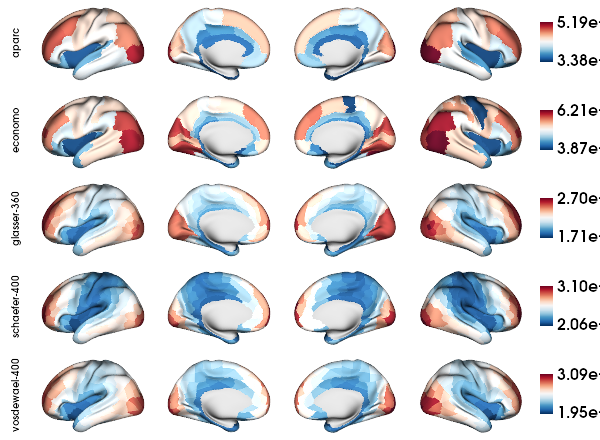

In [20]:
# Parcellations to load
parc = ['aparc', 'economo', 'glasser-360', 'schaefer-400', 'vosdewael-400']
N = len(parc)

# Load the connectome row sum for each parcellation
roi_fs5, roi_32k = load_connectomes('GD', parc, subjectDir, subjectID)

# Plot parcellations
plot_hemispheres(f32k_lh, f32k_rh, array_name=roi_32k[0:N], size=(600, 88*N), cmap='RdBu_r',
                 embed_nb=True, label_text={'left':parc[0:N]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

# GD Connectomes `fsaverage5`

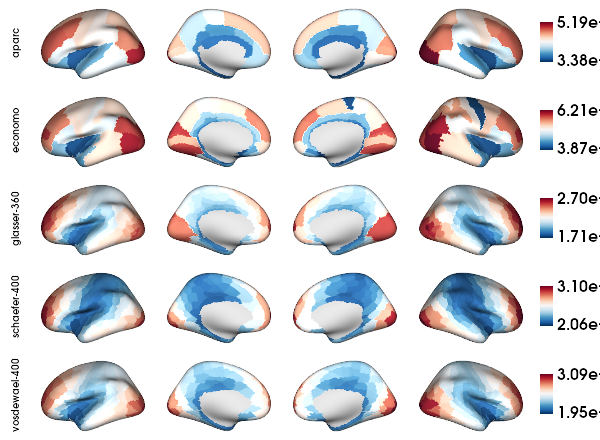

In [21]:
# Plot parcellations
plot_hemispheres(fs5_lh, fs5_rh, array_name=roi_fs5[0:N], size=(600, 88*N), cmap='RdBu_r',
                 embed_nb=True, label_text={'left':parc[0:N]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

# Structural Connectomes `fsLR-32k`

/host/yeatman/local_raid/temporaryLocalProcessing/ipykernel_1111761/3481715255.py:57: RuntimeWarning: divide by zero encountered in log
  mtx_sc = np.log(np.triu(mtx_sc,1)+mtx_sc.T)


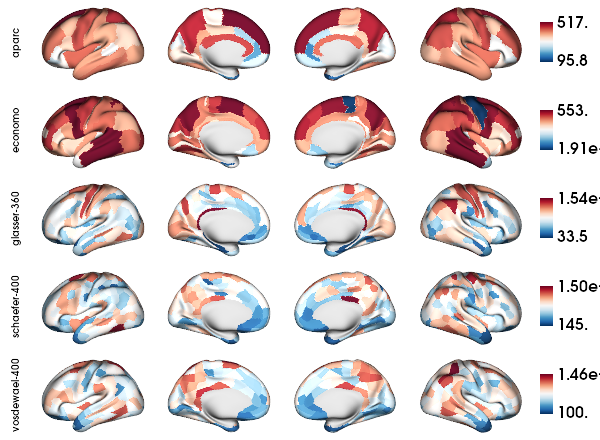

In [22]:
# Load the connectome row sum for each parcellation
roi_fs5, roi_32k = load_connectomes('SC', parc, subjectDir, subjectID)

# Plot parcellations
plot_hemispheres(f32k_lh, f32k_rh, array_name=roi_32k[0:N], size=(600, 88*N), cmap='RdBu_r',
                 embed_nb=True, label_text={'left':parc[0:N]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

# Structural Connectomes `fsaverage5`

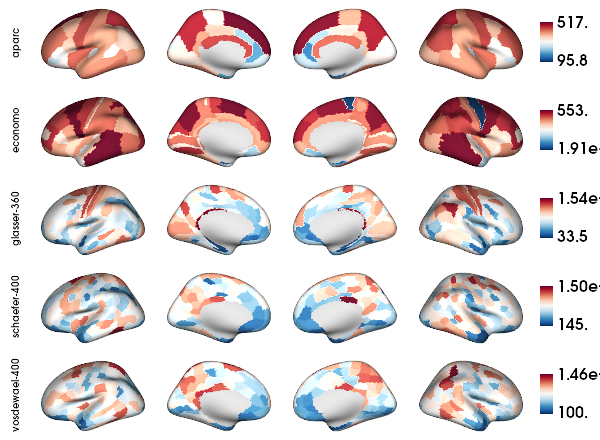

In [23]:
# Plot parcellations
plot_hemispheres(fs5_lh, fs5_rh, array_name=roi_fs5[0:N], size=(600, 88*N), cmap='RdBu_r',
                 embed_nb=True, label_text={'left':parc[0:N]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

# MPC Connectomes `fsLR-32k`

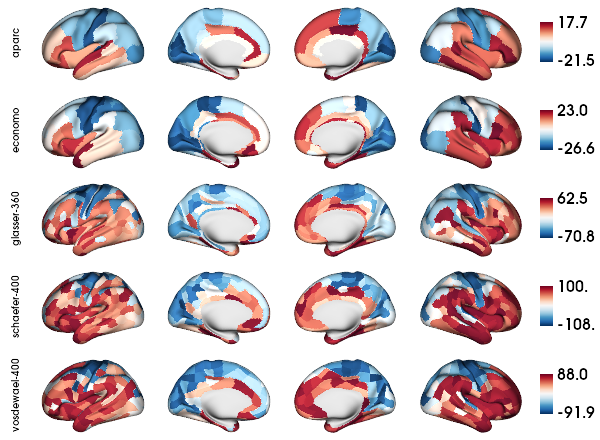

In [24]:
# Load the connectome row sum for each parcellation
roi_fs5, roi_32k = load_connectomes('MPC', parc, subjectDir, subjectID)

# Plot parcellations
plot_hemispheres(f32k_lh, f32k_rh, array_name=roi_32k[0:N], size=(600, 88*N), cmap='RdBu_r',
                 embed_nb=True, label_text={'left':parc[0:N]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

# MPC Connectomes `fsaverage5`

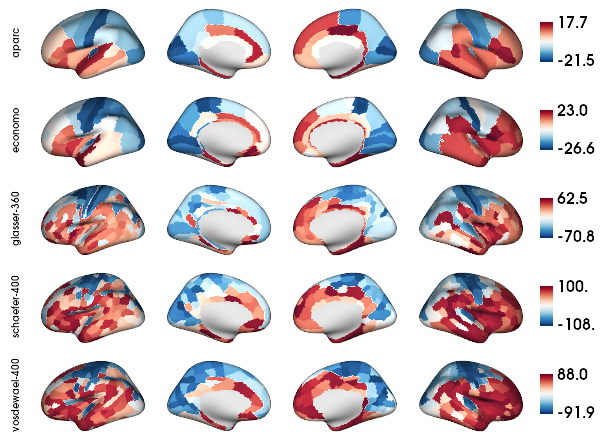

In [25]:
# Plot parcellations

plot_hemispheres(fs5_lh, fs5_rh, array_name=roi_fs5[0:N], size=(600, 88*N), cmap='RdBu_r',
                 embed_nb=True, label_text={'left':parc[0:N]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

# FC Connectomes `fsLR-32k`

/host/yeatman/local_raid/temporaryLocalProcessing/ipykernel_1111761/3481715255.py:26: RuntimeWarning: divide by zero encountered in arctanh
  FCz = np.arctanh(FC)


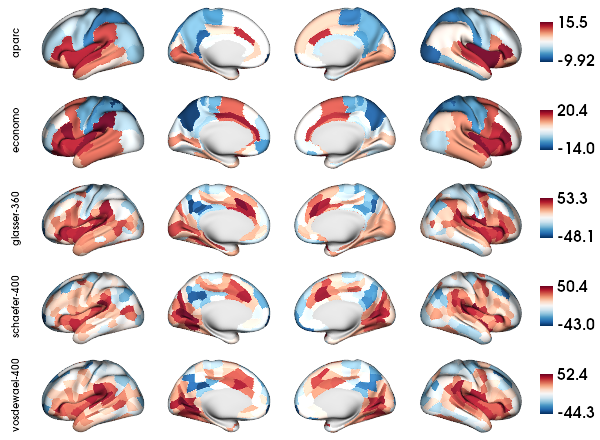

In [26]:
# Load the connectome row sum for each parcellation
roi_fs5, roi_32k = load_connectomes('FC', parc, subjectDir, subjectID)

# Plot parcellations
plot_hemispheres(f32k_lh, f32k_rh, array_name=roi_32k[0:N], size=(600, 88*N), cmap='RdBu_r',
                 embed_nb=True, label_text={'left':parc[0:N]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)

# FC Connectomes `fsaverage5`

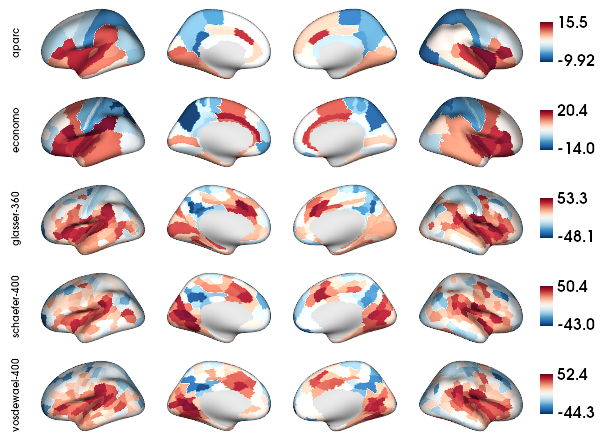

In [27]:
# Plot parcellations

plot_hemispheres(fs5_lh, fs5_rh, array_name=roi_fs5[0:N], size=(600, 88*N), cmap='RdBu_r',
                 embed_nb=True, label_text={'left':parc[0:N]}, color_bar='right',
                 zoom=1.5, nan_color=nan_col)